# Analysis of single anomalies discussed in thesis 

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from anomaly.constants import (
    SDSS_NEBULAR_LINES_FLUX_NAMES, SDSS_NEBULAR_LINES_RATIOS_NAMES
)
from astroExplain.spectra.astronomy import BPT
from sdss.metadata import MetaData

meta = MetaData()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Custom functions

# Config

## Constants

In [2]:
se_cols = ["mse", "mse_filter_250", "mse_97", "mse_filter_250_97"]
se_rank_cols = [f"rank_{col}" for col in se_cols]
# ----------------------------------------------
rse_cols = [f"{col}_rel" for col in se_cols]
rse_rank_cols = [f"rank_{col}_rel" for col in se_cols]
# ----------------------------------------------
se_family = ["mse", "mse_97", "mse_filter_250", "mse_filter_250_97"]
rse_family = [f"{col}_rel" for col in se_family]
# ----------------------------------------------
latent_scores = ["lof", "iforest"]
# ----------------------------------------------
all_scores = se_cols + rse_cols + latent_scores

## Directories

In [3]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
explanations_dir = f"{data_dir}/explanations"

# Data

In [4]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
universal_anomalies_ids = np.load(
    f"{explanations_dir}/bin_03/common_ids_all_scores.npy", mmap_mode="r"
)

# EDA

## Fluxes

```python
n_nans = meta_with_ratios_df[SDSS_NEBULAR_LINES_FLUX_NAMES].isna().sum()
n_negatives = (meta_with_ratios_df[SDSS_NEBULAR_LINES_FLUX_NAMES] < 0).sum()
n_zeros = (meta_with_ratios_df[SDSS_NEBULAR_LINES_FLUX_NAMES] == 0).sum()
temp_df = pd.DataFrame(
    {"n_nans": n_nans, "n_negatives": n_negatives, "n_zeros": n_zeros}
)
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df
```
**Output**
```python
	line_flux_column	n_nans	n_negatives	n_zeros
0	oii_3726_flux	113662	0	0
1	oii_3729_flux	111609	0	0
2	h_beta_flux	55827	0	0
3	oiii_4959_flux	144696	0	0
4	oiii_5007_flux	38664	0	0
5	oiii_flux	40992	0	0
6	h_alpha_flux	24197	0	0
7	nii_6548_flux	40912	0	0
8	nii_6584_flux	40912	0	0
9	sii_6717_flux	94633	0	0
10	sii_6731_flux	120229	0	0
```

## Ratios

```python
n_nans = meta_with_ratios_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].isna().sum()
n_negatives = (meta_with_ratios_df[SDSS_NEBULAR_LINES_RATIOS_NAMES] < 0).sum()
n_zeros = (meta_with_ratios_df[SDSS_NEBULAR_LINES_RATIOS_NAMES] == 0).sum()
temp_df = pd.DataFrame(
    {"n_nans": n_nans, "n_negatives": n_negatives, "n_zeros": n_zeros}
)
temp_df.index.name = "line_ratio_column"
temp_df = temp_df.reset_index()
temp_df
```
**output:**
```python
	line_ratio_column	n_nans	n_negatives	n_zeros
0	balmer_decrement	70406	0	0
1	nii_to_halpha	57496	0	0
2	oiii_to_hbeta	82868	0	0
3	oiii_to_oii	135126	0	0
4	sii_to_halpha	175617	0	0
5	sii_density_ratio	170157	0	0
6	o3n2_index	114190	217324	0
```

```python
# Compute percentiles (45th to 55th percentiles) for each column
percentiles = np.arange(0.45, 0.55, 0.05)
# Create a DataFrame of percentiles for each column in fluxes_df[lines_cols]
ratios_percentiles_df = meta_with_ratios_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].quantile(
    q=percentiles
).T
# Optionally rename the rows as "10th", "20th", etc.
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
# Display the result
ratios_percentiles_df
```
**output:**
```python
45th	50th	55th
balmer_decrement	3.768733	3.914880	4.063091
nii_to_halpha	0.420978	0.456375	0.499100
oiii_to_hbeta	0.643393	0.743624	0.861812
oiii_to_oii	0.677151	0.735276	0.802389
sii_to_halpha	0.342261	0.359278	0.378422
sii_density_ratio	1.369007	1.400479	1.432541
o3n2_index	0.087218	0.134590	0.184831
```

# Common Residual anomalies

```python
overview_common_dict = {
    # row 1
    "narrow_line": 734111514142730240,
    "broad_line_large_OIII": 1633733043925575680,
    # row 2
    "broad_emission_dips_OIII_half": 1192355533059811328,
    "star_forming_step_blue_slope": 1959124163192973312,
    # row 3
    "blue_bump_emission": 531492683672217600,
    "passive_star": 1780176998165932032,
    # row 4
    "spike": 1413149843194406912,
    "noise_forest": 637325355518027776,
}

ratios_dict = {
    "specobjid": [],
    "name": [],
    "balmer_decrement": [],
    "nii_to_halpha": [],
    "oiii_to_hbeta": [],
    "oiii_to_oii": [],
    "o3n2_index": [],
    "sii_to_halpha": [],
    "sii_density_ratio": [],
}


for title, specid in overview_common_dict.items():
    ratios_dict["name"].append(title)
    ratios_dict["specobjid"].append(specid)
    for col in SDSS_NEBULAR_LINES_RATIOS_NAMES:
        try:
            ratios_dict[col].append(meta_with_ratios_df.loc[specid, col])
        except KeyError:
            ratios_dict[col].append(np.nan)
common_ratios_df = pd.DataFrame(ratios_dict)
common_ratios_df.to_clipboard()
common_ratios_df
```
** Output:**
```python

specobjid	name	balmer_decrement	nii_to_halpha	oiii_to_hbeta	oiii_to_oii	o3n2_index	sii_to_halpha	sii_density_ratio
0	734111514142730240	narrow_line	3.293360	0.050160	3.990424	NaN	1.900664	0.163502	1.362553
1	1633733043925575680	broad_line_large_OIII	3.891876	0.204359	10.550430	11.752099	1.712876	0.217171	1.109206
2	1192355533059811328	broad_emission_dips_OIII_half	5.013954	0.599002	8.754367	7.460670	1.164797	0.344767	1.184883
3	1959124163192973312	star_forming_step_blue_slope	3.437888	0.182478	1.409797	0.595381	0.887945	0.278217	1.376201
4	531492683672217600	blue_bump_emission	3.584317	0.371369	0.517071	0.429446	0.143744	0.333807	1.389607
5	1780176998165932032	passive_star	NaN	NaN	NaN	0.123804	NaN	NaN	NaN
6	1413149843194406912	spike	NaN	NaN	NaN	NaN	NaN	NaN	NaN
7	637325355518027776	noise_forest	5.763929	0.055846	0.861052	0.411711	1.188040	NaN	NaN
```

```python
class_common_dict = {
    "specobjid": [],
    "name": [],
    "class": [],
}

for title, specid in overview_common_dict.items():

    class_common_dict["name"].append(title)
    class_common_dict["specobjid"].append(specid)
    try:
        class_ = meta_with_ratios_df.loc[specid, "subClass"]
        class_common_dict["class"].append(class_)
    except KeyError:
        class_common_dict["class"].append(np.nan)

class_common_df = pd.DataFrame(class_common_dict)
class_common_df.to_clipboard()
class_common_df
```

# Unique Residual anomalies

# Universal anomaly

Text(0.5, 0, '$\\lambda$ [nm]')

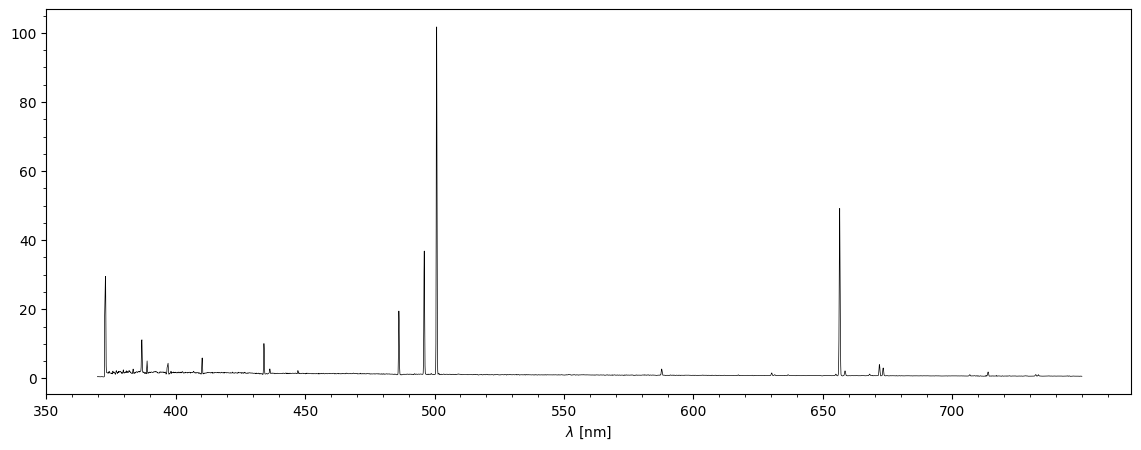

In [15]:
# plot spectrum
spec_objid = 561847176611784704
idx_spec = np.where(idx_id_spec == spec_objid)[0][0]
spec = spectra[idx_spec]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wave_nm, spec, color="black", lw=0.5)
wave_grid = np.arange(350, 750, 50)
ax.set_xticks(wave_grid)
ax.minorticks_on()
ax.set_xlabel(r"$\lambda$ [nm]")

In [6]:
spec_objid = 561847176611784704
universal_ratio_df = meta_with_ratios_df.loc[
    spec_objid, ["subClass"] + SDSS_NEBULAR_LINES_RATIOS_NAMES
]
universal_ratio_df.to_clipboard()
universal_ratio_df

subClass             STARBURST
balmer_decrement      3.231539
nii_to_halpha         0.029984
oiii_to_hbeta         5.560067
oiii_to_oii                NaN
sii_to_halpha         0.117864
sii_density_ratio     1.410144
o3n2_index            2.268194
Name: 561847176611784704, dtype: object

n2_ha: [np.float64(-1.523113949023189)], o3_hb: [np.float64(0.745080008228088)]


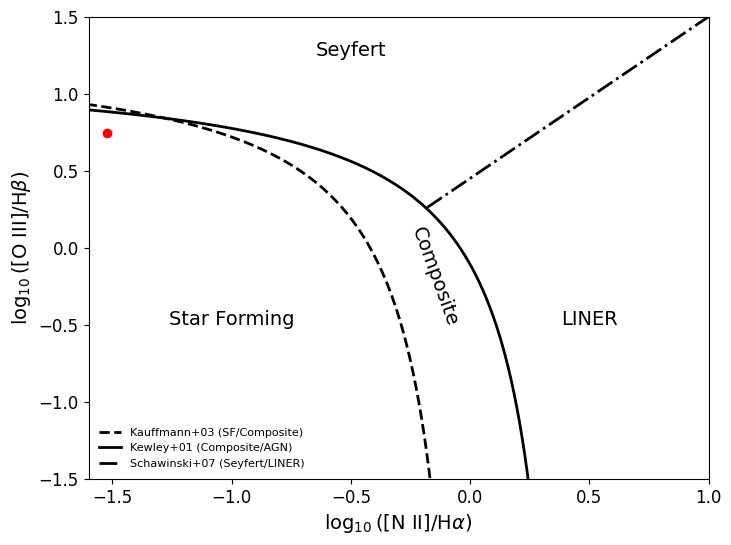

In [12]:
n2_ha = [np.log10(universal_ratio_df["nii_to_halpha"])]
o3_hb = [np.log10(universal_ratio_df["oiii_to_hbeta"])]
print(f"n2_ha: {n2_ha}, o3_hb: {o3_hb}")
labels = [""]

fig, ax = plt.subplots(figsize=(8, 6))
fig, ax = BPT.standar_bpt_plot(
    fig=fig,
    ax=ax,
    n2_ha=n2_ha,
    o3_hb=o3_hb,
    labels=labels,
    xytext=(0, 0),
    x_lim=[-1.6, 1.0],
    y_lim=[-1.5, 1.5],
)

# All universal anomalies

In [22]:
universal_ratio_df = meta_with_ratios_df.loc[
    universal_anomalies_ids, ["subClass"] + SDSS_NEBULAR_LINES_RATIOS_NAMES
]
universal_ratio_df.head()


,subClass,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,sii_to_halpha,sii_density_ratio,o3n2_index
specobjid,,,,,,,,
1767703038748813312,STARBURST,3.620630,0.154643,3.120333,3.640615,0.156881,1.257419,1.304872
3146893614714480640,STARBURST,3.625227,0.022095,5.559329,NaN,0.082151,1.385004,2.400723
2504067977276581888,STARBURST,3.305240,0.174236,2.245193,2.285401,0.177838,1.403361,1.110117
2987116977425770496,STARBURST,3.164824,0.049836,4.872758,5.503056,0.117105,1.328709,1.990228
2383573327655495680,STARBURST,3.351260,0.111678,3.046099,2.760903,0.161429,1.296902,1.435777
